In [ ]:
!pip install -q langchain langchain-groq

In [ ]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

LangChain provides an integration with the Groq API, so once our API Key is set we can inference the Groq LLMs via langchain.

You can access all the models mentioned here: [Groq/Models](https://console.groq.com/docs/models)

You can learn more about LangChain Chat models here: [LangChain Models](https://docs.langchain.com/oss/python/langchain/models)



In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

### **Basic LLM calling**
This is the first step to get familiar with the LangChain ecosystem. We'll do inferencing with Groq API via the LangChain Chat wrapper.

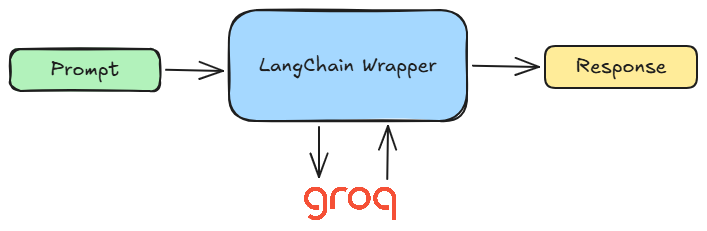

In [ ]:
resp = llm.invoke("What is the capital of India?")
print(resp.content)

### **LLM Call with System Prompt**

In LangChain, we can represnt the input and output from various entitis as messages, which act as context for the models.

Message types
 - **System message** - Tells the model how to behave and provide context for interactions
 - **Human message** - Represents user input and interactions with the model
 - **AI message** - Responses generated by the model, including text content, tool calls, and metadata
 - **Tool message** - Represents the outputs of tool calls


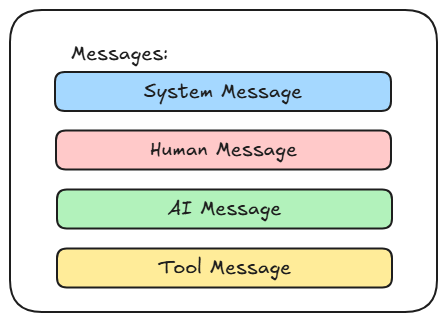

In [ ]:
response = llm.invoke(
    [
      (
          "system",
          "You are a helpful assistant that reviews python code and suggests improvement",
      ),
      ("human", """
  def process_data(data_list):
    for item in data_list:
        if "@" in item:
            print("Email:", item)
        else:
            try:
                num = int(item)
                print("Number:", num * 2)
            except:
                print("Other:", item)

      """),
    ]
)

print(response.content)

# **Building RAG Pipeline in LangChain**

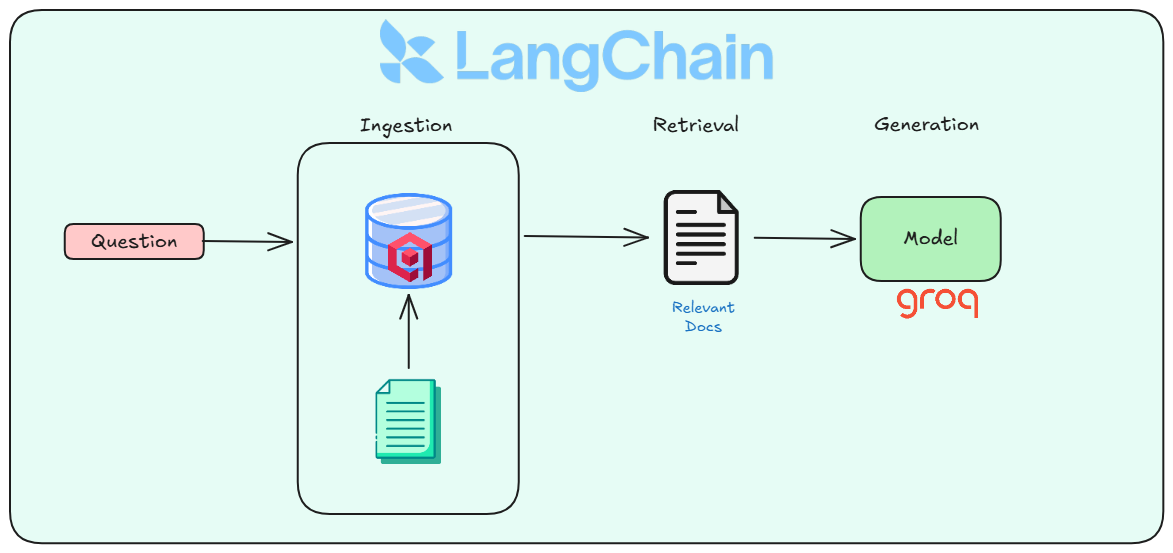

In [22]:
# Installing Dependencies

!pip install -q langchain langchain-community langchain-huggingface langchain-qdrant langchain-groq
!pip install -q langchain-docling          # official Docling ↔ LangChain integration
!pip install -q docling docling-core
!pip install -q sentence-transformers qdrant-client

In [3]:
import os
from langchain_docling import DoclingLoader
from langchain_docling.loader import ExportType
from docling_core.transforms.chunker import HierarchicalChunker
from langchain_core.prompts import ChatPromptTemplate
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_groq import ChatGroq
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams

### **Parse Load & Chunk Document**

**What happens in docling:**
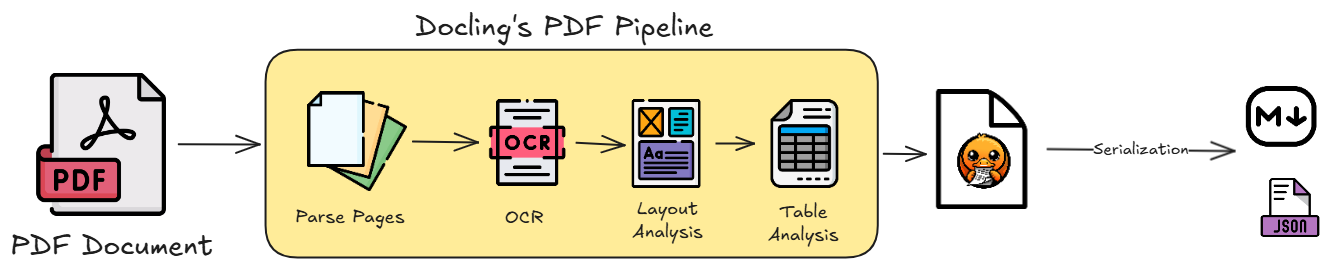

<br>
<br>
<br>

**LangChain Takes it a few steps further**
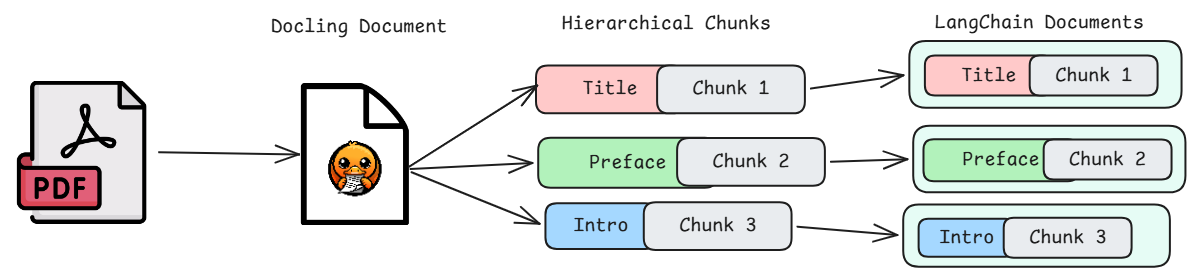

In [4]:
SOURCE = "https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/AtliqAI_HR_Policies.pdf"

documents = DoclingLoader(
    file_path=SOURCE,
    export_type=ExportType.DOC_CHUNKS,
    chunker=HierarchicalChunker(),
).load()

[INFO] 2026-03-15 11:16:41,931 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-15 11:16:41,937 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-15 11:16:41,942 [RapidOCR] download_file.py:68: Initiating download: https://www.modelscope.cn/models/RapidAI/RapidOCR/resolve/v3.7.0/torch/PP-OCRv4/det/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-15 11:16:43,098 [RapidOCR] download_file.py:82: Download size: 13.83MB
[INFO] 2026-03-15 11:16:43,360 [RapidOCR] download_file.py:95: Successfully saved to: /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-15 11:16:43,366 [RapidOCR] main.py:50: Using /usr/local/lib/python3.12/dist-packages/rapidocr/models/ch_PP-OCRv4_det_infer.pth
[INFO] 2026-03-15 11:16:43,644 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-03-15 11:16:43,645 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-03-15 11:16:43,647 [RapidOCR] download_file.py:68: Initiating download: https://

In [7]:
documents[1]

Document(metadata={'source': 'https://raw.githubusercontent.com/tnahddisttud/sample-doc/refs/heads/main/AtliqAI_HR_Policies.pdf', 'dl_meta': {'schema_name': 'docling_core.transforms.chunker.DocMeta', 'version': '1.0.0', 'doc_items': [{'self_ref': '#/texts/4', 'parent': {'$ref': '#/body'}, 'children': [], 'content_layer': 'body', 'label': 'text', 'prov': [{'page_no': 1, 'bbox': {'l': 33.301339386, 't': 663.5378539234003, 'r': 561.7109450099603, 'b': 637.0929768364473, 'coord_origin': 'BOTTOMLEFT'}, 'charspan': [0, 452]}]}], 'headings': ['Offer and Joining Formalities'], 'origin': {'mimetype': 'application/pdf', 'binary_hash': 257296305029141490, 'filename': 'AtliqAI_HR_Policies.pdf'}}}, page_content='Offer and Joining Formalities\nUpon acceptance of an offer letter, candidates must complete the joining formalities within the stipulated date mentioned in the offer. The HR team will share a prejoining checklist that includes submission of educational certificates, identity proof, address 

### **Indexing**

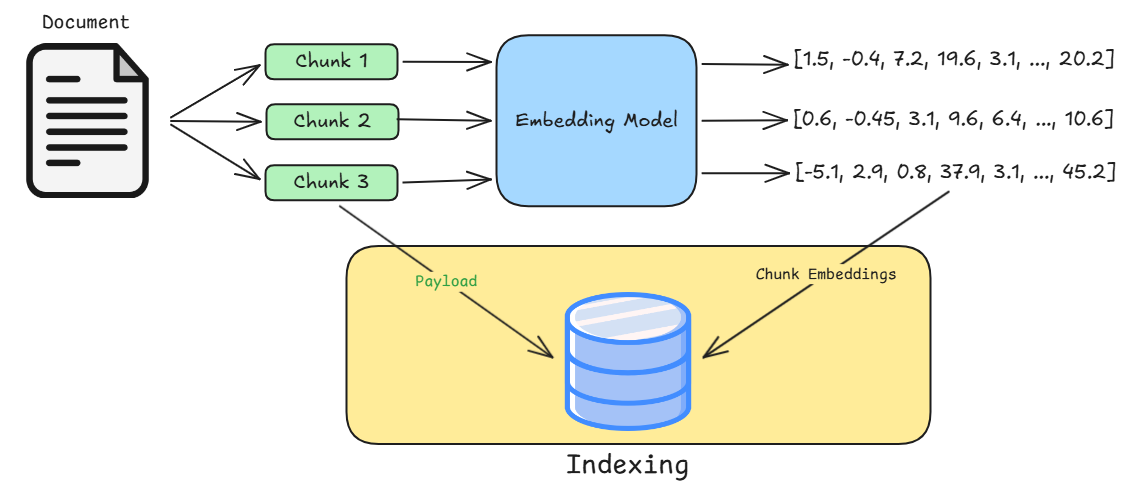

In [8]:
EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"

embeddings = HuggingFaceEmbeddings(model_name=EMBED_MODEL_ID)

In [12]:
vectorstore = QdrantVectorStore.from_documents(
    documents=documents,
    embedding=embeddings,
    path="/tmp/my_lang_vs",
    collection_name="hr_docs",
)

## **Retrieval**

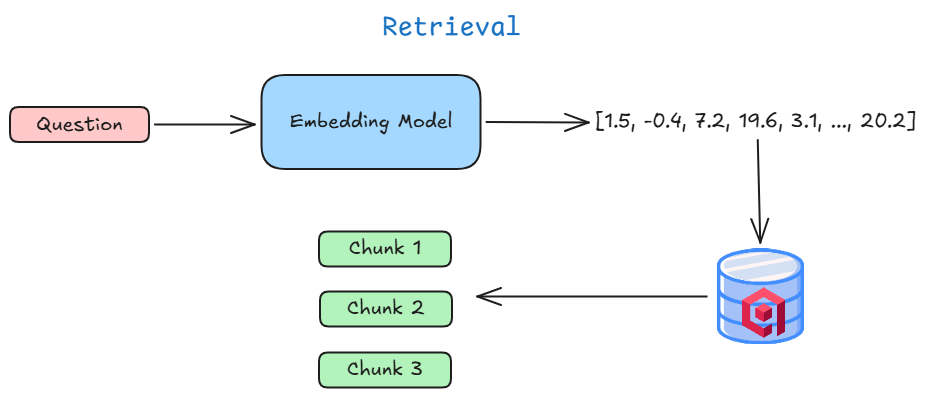

In [13]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

## **RAG Pipeline**

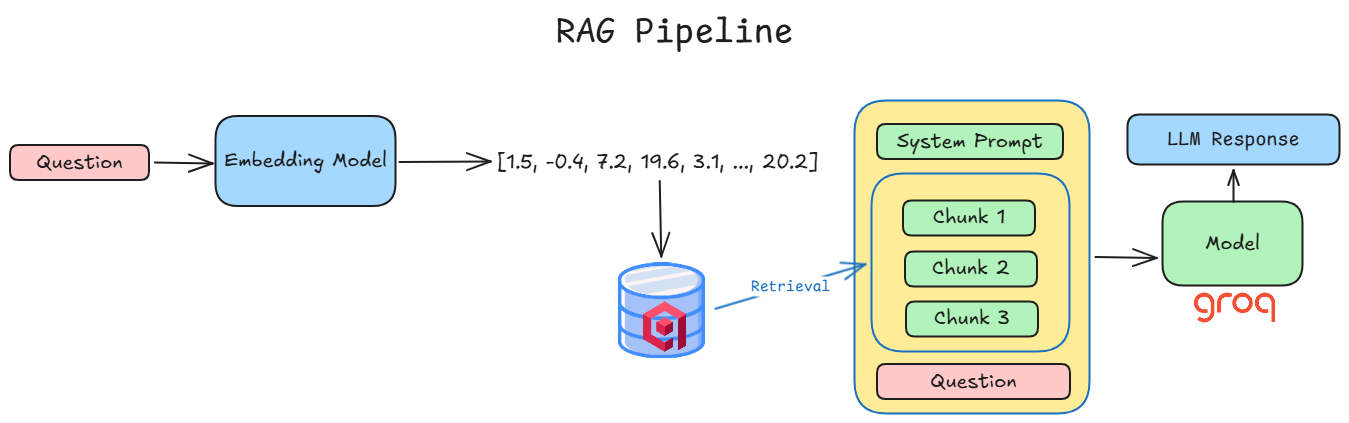

In [14]:
RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "Answer using ONLY the context below. Cite section names. Say 'I don't know' if unsure."),
    ("human", "Context:\n{context}\n\nQuestion: {question}")
])

In [16]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [17]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

In [18]:
def format_docs(docs):
    parts = []
    for i, doc in enumerate(docs, 1):
        dl_meta  = doc.metadata.get("dl_meta", {})
        headings = dl_meta.get("headings", [])
        source   = " > ".join(headings) if headings else "Unknown"
        parts.append(f"[{i}] {source}\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

In [19]:
def rag(query: str) -> str:
    docs         = retriever.invoke(query)
    context      = format_docs(docs)
    prompt_value = RAG_PROMPT.invoke({"context": context, "question": query})
    response     = llm.invoke(prompt_value)
    return response.content

In [21]:
for q in [
        "How many casual leaves am I entitled to?",
        "What is the notice period for Band 4 employees?",
        "How long is the probation period?",
    ]:
        print(f"\nQ: {q}\nA: {rag(q)}\n")


Q: How many casual leaves am I entitled to?
A: You are entitled to **12 casual leaves per calendar year**【1】.


Q: What is the notice period for Band 4 employees?
A: The notice period for Band 4 employees is **60 days**【1】.


Q: How long is the probation period?
A: The probation period is **6 months** from the date of joining. (See section [1] Probation Period)

